<a href="https://colab.research.google.com/github/brewburgr/Microparticle-TFM/blob/main/Jupyter%20notebook%20experimental%20%2B%20template/Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [3]:
#@title install packages & cloning repository
!git clone https://github.com/brewburgr/Microparticle-TFM.git
!uv pip install -r "Microparticle-TFM/Jupyter notebook experimental + template/requirements.txt"
# if compability in the future, check requirements_full.txt in github

Cloning into 'Microparticle-TFM'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 54 (delta 0), reused 0 (delta 0), pack-reused 52 (from 2)
Receiving objects: 100% (54/54), 34.55 MiB | 31.42 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Using Python 3.12.12 environment at: /usr
Resolved 47 packages in 452ms
Prepared 7 packages in 4.66s
Installed 7 packages in 28ms
 + boule==0.5.0
 + cyclopts==4.10.0
 + plyfile==1.1.3
 + pyshtools==4.14.1
 + pyvista==0.47.1
 + rich-rst==1.3.2
 + vtk==9.6.0


In [4]:
# @title imports
import numpy as np
import numba
import scipy.integrate
import scipy.special
import scipy.spatial
from scipy.interpolate import RegularGridInterpolator
import os
import numpy.polynomial.legendre as leg
from matplotlib import ticker as tck
import matplotlib as mpl
from datetime import datetime, date
from google.colab import drive
import scipy.io as sio
import matplotlib.patches as patches
import pandas as pd
import tifffile as tif
import scipy as sp
import scipy.sparse as spm
from scipy.sparse.linalg import lsqr, spsolve
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize, Bounds, brute, approx_fprime
from scipy.io import loadmat, savemat

from plyfile import PlyData, PlyElement
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import sys, time, os.path
from itertools import permutations
import pyshtools as _psh
import pyshtools





codepath='/content/Microparticle-TFM/Jupyter notebook experimental + template/modules/'
import sys
sys.path.append(codepath)


from helper_functions import (
    rts, nu, E, distance, lame_mu, lame_lambda,
    vector_sph_to_cart, vector_cart_to_sph, cart_to_sph_coords,
    all_errors_2D_old, AAD_surface, all_errors_2D,
    full5tap3D, full9tap3D, set_axes_equal, visSH3D_data3,
    extendflip, generate_submat, loadCoeffs,
)


from shelastic.shutil import SphCoord_to_CartCoord, CartCoord_to_SphCoord, GLQCartCoord
from shelastic.shutil import SHCilmToVector, SHVectorToCilm, SHVec2mesh, SHmesh2Vec
from shelastic.shutil import TransMat, l_coeffs, m_coeffs, LM_list, lmk2K, K2lmk
from shelastic.shbv   import generate_submat, Uvec2Tvec, Tvec2Uvec
from shelastic.shvis  import plotfv, vismesh, visSHVec, visSH3d
from shelastic.sphere_utils import loadCoeffs, arbitrary_force, Ur_interp
from shelastic.sphere_utils import usurf2umesh, dumesh_dus, usurf2vec, usurf2dr
from shelastic.sphere_utils import Tvec2Tres, usurf2dr2, calculateTfv, genSmat, genLmat, grad_usurf2dr2

/content/Microparticle-TFM/Jupyter notebook experimental + template/modules/shelastic/shelastic.py:5: SyntaxWarning: invalid escape sequence '\m'
  stress basis :math:`\mathbf{\sigma}^{(K)}`, and traction basis :math:`\mathbf{T}^{(K)}`
/content/Microparticle-TFM/Jupyter notebook experimental + template/modules/shelastic/shgrad.py:187: SyntaxWarning: invalid escape sequence '\m'
  .. math:: \mathbf{Y}_l^m(\\theta, \\varphi) = Y_l^m(\\theta, \\varphi) \hat{r}
/content/Microparticle-TFM/Jupyter notebook experimental + template/modules/shelastic/shgrad.py:241: SyntaxWarning: invalid escape sequence '\m'
  .. math:: \mathbf{\Psi}_l^m(\\theta, \\varphi) = r\\nabla Y_l^m(\\theta, \\varphi)


# Template

File can be uploaded here in colab and

In [5]:
#@title import ply/surface file
#plypath='XXX' #Enter path to ply file here
#plydata = PlyData.read(plypath)
#vertex0=plydata['vertex']

# alternatively, provide surface as list of points/nparray in the format below
# vertex0 = [[point1_x,point1_y,point1_z], [point2_x,point2_y,point2_z],...]
numv=len(vertex0)
vertexonly=np.ones((numv,3))

# position bead in middle by substracting means
for n in range(numv):
    for nn in range(3):
        vertexonly[n][nn]=vertex0[n][nn]
means=np.mean(vertexonly,0)
vertexmod=np.zeros_like(vertexonly)
for n in range(numv):
    for nn in range(3):
        vertexmod[n][nn]=(vertexonly[n][nn]-means[nn])
Vp=vertexmod

# Measure radius and volume (here in um^3 and um)
from scipy.spatial import ConvexHull
# Example: N x 3 array of 3D points
# random 3D points
hull = ConvexHull(Vp)
volume = hull.volume
radius = np.cbrt(0.75*volume/np.pi)
print("Convex hull volume:", volume)
print("Radius:", radius)

Convex hull volume: 0.16666666666666666
Radius: 0.34139203162764775


Text(0.5, 0.5, 'y [$\\mu$m]')

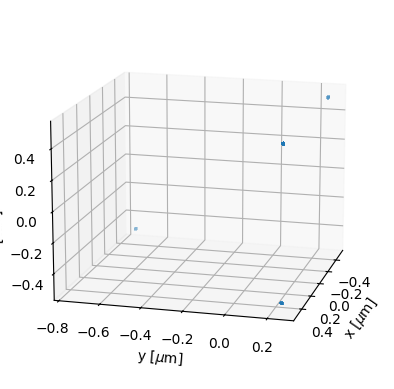

In [6]:
#@title plot surface points
fig,ax=plt.subplots(1,1,subplot_kw={"projection": "3d"})
ax.view_init(15,15)
ax.scatter3D(vertexmod[:,0],vertexmod[:,1],vertexmod[:,2],antialiased=False, s=2)

ax.set_zlabel(r'z [$\mu$m]')
ax.set_xlabel(r'x [$\mu$m]')
ax.set_ylabel(r'y [$\mu$m]')


In [8]:
#@title Set experimental parameters
# Data file name
shapename = "Experiment"

# Material properties - calculate lame parameter from E0 and nu0
E0=1100 #Elastic modulus
nu0 = 0.4 # Poisson ratio

mu0 = lame_mu(E0, nu0);
r0 = radius           # microns


# Spherical Harmonics Analysis Settings
lJmax = 20; lKmax = lJmax; lmax_plot = 60;
lmax_gen=200
noise_level=0

# initial guess settings
init_guess_type = 'ur-only' #'ur-only' or 'true'

# regularizations
myalpha = 1     # traction magnitude
mybeta  = 1  # coefficient magnitude
mygamma = 0.3   # anti-aliasing parameter     (beta  in the paper)

# program switches
plot_figure = True
savefig = False
myord = 1; # myord: p-norm order (1-mean value)

# minimization settings
maxiter_per_period = 20
CG_gtol = 1e-7          # This determines how good we want the analysis to be
eps = 1e-4              # for jacobian

minimizer = 'CG'
minimizer_config = {'maxiter': maxiter_per_period, 'disp': True, 'gtol': CG_gtol}

# dump files for minimization
savename = shapename + ('_b%.0f_n%.1e_lmax%d'%(mybeta, noise_level, lJmax))


In [9]:
#@title Optimization Functions
def prep_run():
    target_args = (f_interp, lJmax, mybeta, myord, X0surf, X0, isTfv, Cmat, Dmat,
               mu0, nu0, np.array([1]), np.array([1]), eps, '2-point', (TresJac, EelJac, penJac), mygamma)
    u_surf = u0_surf.flatten().copy()

    print(u0_surf.shape)
    u_surf_list = [u_surf, ]
    tic_start = time.time()
    return target_args,u_surf_list
def get_damping():
    lmax = lJmax
    ldamp_hi = lmax; ldamp_lo = lmax - 5;
    lv, _ = LM_list(lmax); lv_ones = np.ones_like(lv);
    lv_lim = np.minimum(np.maximum(lv, ldamp_lo), ldamp_hi)
    ldamp = (np.maximum(lv_lim-ldamp_lo, 0) / (ldamp_hi - ldamp_lo))**1
    Q = spm.csr_matrix(np.diag(np.tile(ldamp, 3)).astype(complex))
    return Q

def get_Jacobians(printtimes=False):
    Q=get_damping()
    # Calculating L, S, P matrices for Jacobian evaluation
    tic = time.time()
    Lmat = genLmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating L matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    Smat = genSmat(lJmax, Cmat=Cmat, Dmat=Dmat)
    if printtimes:
        print('Time for generating S matrix: %.2fs'%(time.time() - tic))
    Dinv = spm.linalg.inv(Dmat)
    CDmat = Cmat.dot(Dinv)
    tic = time.time()
    CDSmat = np.asmatrix(CDmat.dot(Smat))
    SHCDS = np.asmatrix(Smat).H.dot(CDSmat)
    if printtimes:
        print('Time for generating S^HCD^{-1}S matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    QCDSmat = Q.dot(CDSmat)
    QCDSHQCDS = QCDSmat.H.dot(QCDSmat).real
    if printtimes:
        print('Time for generating QCDSHQCDS matrix: %.2fs'%(time.time() - tic))
    tic = time.time()
    P = np.diag(np.stack([isTfv]*3, axis=-1).flatten())
    TresJac = myalpha*2*np.asmatrix(np.dot(np.dot(Lmat.T, P), Lmat))/(lJmax+1)/(lJmax*2+1)
    EelJac  = mybeta*2*np.pi*(SHCDS+SHCDS.H)
    penJac  = mygamma*(QCDSHQCDS+QCDSHQCDS.H)
    if printtimes:
        print('time of matrix build:', time.time() - tic)
    return TresJac, EelJac, penJac, Q

def get_interp(print_res=False):
    f_interp = Ur_interp(Vp/r0, lmax=lJmax+20, plot_figure=plot_figure)
    # Define shape reference points
    latsdeg, lonsdeg = pyshtools.expand.GLQGridCoord(lJmax, extend=True)
    lon0, lat0 = np.meshgrid(lonsdeg, latsdeg)
    X0surf = np.stack([lat0, lon0], axis=-1)
    X0 = GLQCartCoord(lJmax)
    u0_surf = np.zeros((lJmax+1, lJmax*2+2, 2))
    if print_res:
        U0vec, aK, T0vec = usurf2vec(u0_surf, f_interp=f_interp, lmax=lJmax)
    return f_interp, X0surf, X0, u0_surf

def print_residual_E_el():
    T0dist = Tvec2Tres(T0vec, lJmax, isTfv=isTfv, norm_order=myord)
    E0el = np.vdot(U0vec, T0vec).real*2*np.pi
    print('Traction residual: %.4e Pa'%(np.sqrt(T0dist)*mu0))
    print('Elastic energy: %.4e pJ'%(E0el*(r0/1e6)**3*mu0*1e12))
    print('funval: %.4e %.4e'%(T0dist, E0el))

def print_iter(xk):
    Uvec, aK, Tvec = usurf2vec(xk, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
    Tdist = Tvec2Tres(Tvec, lJmax, isTfv=isTfv, norm_order=myord)
    Eel = np.vdot(Uvec, Tvec).real*2*np.pi
    pen = np.vdot(Q.dot(Tvec), Q.dot(Tvec)).real
    dr  = usurf2dr2(xk, *target_args)
    print('%13.4ePa%13.4epJ%13.4e%13.4e%13.4e%13.4e'%(np.sqrt(Tdist)*mu0, Eel*(r0/1e6)**3*mu0*1e12, Tdist, Eel, pen, dr))

def run_iters(N_iterations,usurfload=False):
    u_surf=u_surf_list[-1]
    tic_start = time.time()
    for i in range(N_iterations):
        print('Period %4d  Tr'%i, ' '*10, 'Eel', ' '*9, 'f0',' '*9, 'f1', ' '*9, 'f2', ' '*9, 'f')
        tic = time.time()
        u_res = minimize(usurf2dr2, u_surf.flatten(), args=target_args, jac=grad_usurf2dr2,
                        method = minimizer, options=minimizer_config, callback=print_iter)
        print('Iteration Time: %.2fs'%(time.time() - tic))
        u_surf = u_res.x.copy()
        u_surf_list.append(u_surf)
        if u_res.success:
            break
    print('Total Wall Time: %.2fs'%(time.time() - tic_start))
    return u_surf


In [10]:
#@title Load Matrices for optimization
Cmat, Dmat = loadCoeffs(mu0, nu0, lJmax, 'reg',coeff_dir='/content/Microparticle-TFM/Jupyter notebook experimental + template/modules/default_modes')

Integrating modes to a matrix
1323 1323
Integrating modes to a matrix
1323 1323


## Option - define traction free region
isTfv has format (nlatitudepoints, nlongitudepoints), following the GLQ grid. Entries can be set to "True" to define traction-free region. Default here is no traction-free region.

Entry (0,...) corresponds to north pole, (lJmax/2,...) to the equator points. Entry (...,0) corresponds to (using spherical coordinates) φ=0,  (...,lJmax/2) to φ ∼ π/2, etc.

In [11]:
isTfv=np.zeros((lJmax+1,2*(lJmax+1)),dtype=bool)

shape fitting accuracy: 0.0


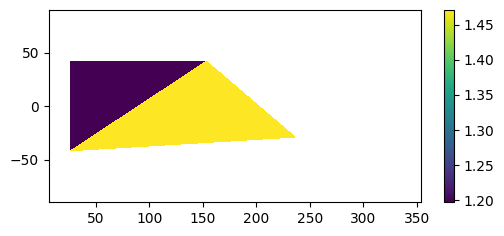

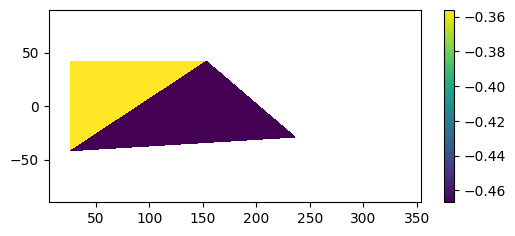

In [12]:
#@title Create other matrices and conversion of surface file into GLQ
TresJac, EelJac, penJac,Q = get_Jacobians()
f_interp, X0surf, X0, u0_surf=get_interp()


In [ ]:
#@title Perform optimization
target_args,u_surf_list= prep_run()
u_surf=run_iters(2)

(21, 42, 2)
Period    0  Tr            Eel           f0           f1           f2           f
   0.0000e+00Pa   1.3402e-01pJ   0.0000e+00   9.3929e-02   6.8354e-03   9.5980e-02
   0.0000e+00Pa   1.2574e-01pJ   0.0000e+00   8.8126e-02   1.7864e-03   8.8662e-02
   0.0000e+00Pa   1.2213e-01pJ   0.0000e+00   8.5597e-02   4.0442e-03   8.6810e-02
   0.0000e+00Pa   1.1866e-01pJ   0.0000e+00   8.3160e-02   3.3392e-03   8.4162e-02
   0.0000e+00Pa   1.1685e-01pJ   0.0000e+00   8.1894e-02   1.5795e-03   8.2368e-02
   0.0000e+00Pa   1.1605e-01pJ   0.0000e+00   8.1333e-02   1.2926e-03   8.1721e-02
   0.0000e+00Pa   1.1537e-01pJ   0.0000e+00   8.0857e-02   1.4331e-03   8.1287e-02
   0.0000e+00Pa   1.1458e-01pJ   0.0000e+00   8.0304e-02   1.5643e-03   8.0773e-02
   0.0000e+00Pa   1.1406e-01pJ   0.0000e+00   7.9937e-02   1.3987e-03   8.0357e-02
   0.0000e+00Pa   1.1378e-01pJ   0.0000e+00   7.9742e-02   1.2837e-03   8.0128e-02
   0.0000e+00Pa   1.1366e-01pJ   0.0000e+00   7.9657e-02   1.2066e-03   8.00

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:777: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_cg(fun, x0, args, jac, callback, **options)


   0.0000e+00Pa   1.1160e-01pJ   0.0000e+00   7.8212e-02   7.2826e-04   7.8431e-02
   0.0000e+00Pa   1.1155e-01pJ   0.0000e+00   7.8177e-02   7.1561e-04   7.8391e-02
   0.0000e+00Pa   1.1135e-01pJ   0.0000e+00   7.8043e-02   8.8351e-04   7.8308e-02
   0.0000e+00Pa   1.1083e-01pJ   0.0000e+00   7.7676e-02   8.6428e-04   7.7936e-02
   0.0000e+00Pa   1.1046e-01pJ   0.0000e+00   7.7416e-02   6.6538e-04   7.7615e-02
   0.0000e+00Pa   1.1003e-01pJ   0.0000e+00   7.7116e-02   6.9469e-04   7.7324e-02
   0.0000e+00Pa   1.0989e-01pJ   0.0000e+00   7.7013e-02   6.1758e-04   7.7199e-02
   0.0000e+00Pa   1.0970e-01pJ   0.0000e+00   7.6884e-02   6.7410e-04   7.7086e-02
   0.0000e+00Pa   1.0942e-01pJ   0.0000e+00   7.6689e-02   7.6994e-04   7.6920e-02
   0.0000e+00Pa   1.0893e-01pJ   0.0000e+00   7.6346e-02   7.1769e-04   7.6561e-02
   0.0000e+00Pa   1.0871e-01pJ   0.0000e+00   7.6189e-02   6.4760e-04   7.6384e-02
   0.0000e+00Pa   1.0849e-01pJ   0.0000e+00   7.6033e-02   6.5874e-04   7.6231e-02
   0

Traction residual: 0.0000e+00 Pa
Elastic energy: 1.0570e-01 pJ
funval: 0.0000e+00 7.4083e-02


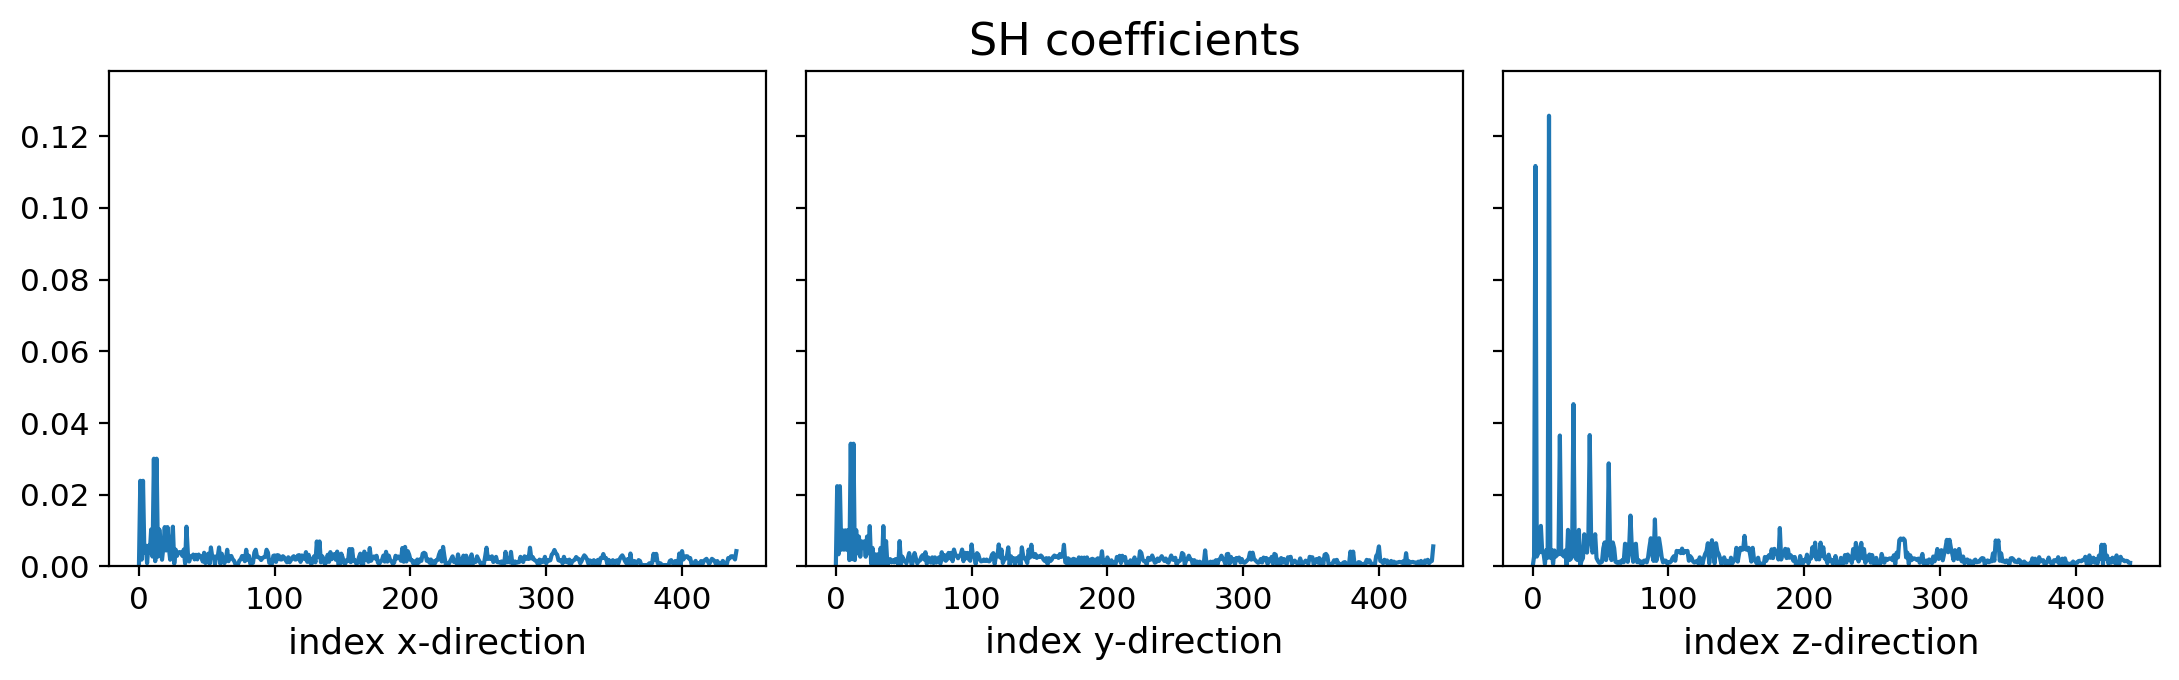

In [ ]:
#@title Evaluation of Spherical harmonic coefficients

Usurfvec, aK, Tsurfvec = usurf2vec(u_surf, f_interp, lJmax, X0surf=X0surf, X0=X0, Cmat=Cmat, Dmat=Dmat)
Tsurfdist = Tvec2Tres(Tsurfvec, lJmax, isTfv=isTfv, norm_order=myord)
Esurfel = np.vdot(Usurfvec, Tsurfvec).real*2*np.pi
print('Traction residual: %.4e Pa'%(np.sqrt(Tsurfdist)*mu0))
print('Elastic energy: %.4e pJ'%(Esurfel*(r0/1e6)**3*mu0*1e12))
print('funval: %.4e %.4e'%(Tsurfdist, Esurfel))

Textsize=16
plt.rcParams['axes.titlesize']=Textsize
plt.rcParams['axes.labelsize']=0.8*Textsize
nrange=None
srange=None
tveclength=len(Tsurfvec)
fig, ax = plt.subplots(1,3,figsize=(11,3.5))

labels=['$T_x$','$T_y$','$T_z$']
labels2=['x','y','z']
maxval=np.nanmax(np.abs(Tsurfvec))
for n in range(3):
    n0=n*int(tveclength/3)
    n1=(n+1)*int(tveclength/3)
    ax[n].tick_params(axis='both', which='major', labelsize=0.7*Textsize)
    ax[n].plot(np.abs(Tsurfvec[n0:n1]))#,  label='Reconstructed',alpha=0.7)

    ax[n].set_ylim(0,maxval*(1.1))
    #ax.legend()
    ax[n].set_xlabel('index '+labels2[n]+'-direction')
    if n!=0:
        ax[n].yaxis.set_ticklabels([])
ax[1].set_title('SH coefficients')

plt.gcf().set_dpi(200)

fig.tight_layout()

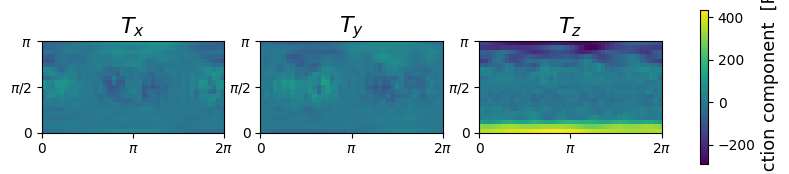

In [ ]:
#@title Evaluation of Traction map
Tmesh=SHVec2mesh(Tsurfvec,SphCoord=False,Complex=True)
T_mesh2=Tmesh*mu0
fig, ax= plt.subplots(1,3, figsize=(10,2))
x=ax[0].imshow(T_mesh2[:,:,0],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
ax[1].imshow(T_mesh2[:,:,1],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
ax[2].imshow(T_mesh2[:,:,2],vmin = np.min(T_mesh2), vmax= np.max(T_mesh2), extent = [0,2*np.pi,0,np.pi])
Titles = [r'$T_x$',r'$T_y$',r'$T_z$']
for n in range(3):
    ax[n].set_title(Titles[n])
for axx in ax:
    axx.set_yticks([0, np.pi/2, np.pi], labels =["0", r"$\pi/2$", r"$\pi$"] )
    axx.set_xticks([0, np.pi, 2*np.pi], labels = ["0", r"$\pi$", r"$2\pi$"])

fig.colorbar(x,ax=ax, label="Traction component  [Pa]")

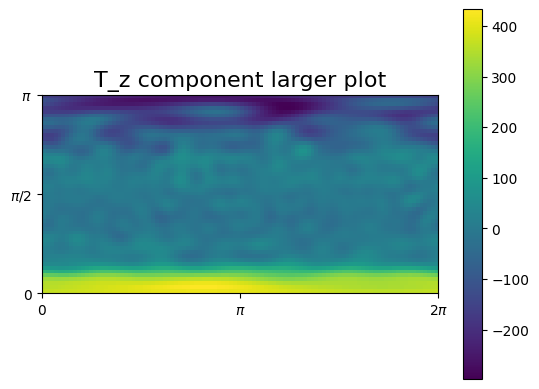

In [ ]:
#@title Evaluation of T_z traction component with high resolution
lplot = 50
radius=1
coord = GLQCartCoord(lplot)*radius
T_fine = SHVec2mesh(Tsurfvec, SphCoord=False, Complex=True, lmax = lplot)*mu0
plt.title("T_z component larger plot")
plt.imshow(T_fine[:,:,2], extent = [0,2*np.pi,0,np.pi])
#axx=plt.gca()
#axx.set_xticklabels(["0","","", r"$\pi$", "","", r"$2\pi$"])
plt.yticks([0, np.pi/2, np.pi], labels =["0", r"$\pi/2$", r"$\pi$"] )
plt.xticks([0, np.pi, 2*np.pi], labels = ["0", r"$\pi$", r"$2\pi$"])
plt.colorbar()